# Libraries

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [34]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240605 - Ag60 GDE_0.6 M K2SO4_pH2

10-Aug-26  04:49 PM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  08:28 PM    <DIR>          .ipynb_checkpoints
07-Jun-24  03:02 PM            86,996 0p6M_pH2 K2SO4_20240607_1301_1min - Copy.xlsx
29-Jul-26  05:49 PM           103,550 0p6M_pH2 K2SO4_20240607_1301_1min.xlsx
07-Jun-24  03:02 PM            22,037 0p6M_pH2 K2SO4_20240607_1301_5min.xlsx
07-Jun-24  03:02 PM           699,826 0p6M_pH2 K2SO4_20240607_1301_Line_1.csv
17-Jul-26  11:25 AM           917,401 20240605 - Ag60 GDE_0.6 M K2SO4_pH2.ipynb
07-Aug-26  02:56 PM           750,012 20240605 - Ag60 GDE_0.6 M K2SO4_pH2-CORRECTED.ipynb
04-Aug-26  08:53 AM               565 20240605_0.6 M K2SO4_pH2_Energy Consumption.csv
03-Aug-26  05:26 PM             5,323 20240605_0.6M K2SO4_pH2.csv
03-Aug-26  05:49 PM               774 20

# Load Data

In [35]:
Book = "Book_20240605 - Ag60 GDE_0.6 M K2SO4_pH2.xlsx"
Book = pd.read_excel(Book)
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,Ag60 GDE in PTFE holder,60,61.011019,0.3 M K2SO4,Deionized wated,CCM-CEM,0.00,2024-06-05 17:41:57.463,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
1,Ag60 GDE in PTFE holder,60,61.710321,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 17:55:34.000,0.226816,0.477477,...,3.606827e-05,0.303658,0.444027,NaN,0.747684,0.006555,NaN,NaN,NaN,NaN
2,Ag60 GDE in PTFE holder,60,62.257727,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 18:18:06.000,0.602371,1.340128,...,7.900348e-06,0.858769,0.109686,NaN,0.968455,0.001618,105.795432,NaN,NaN,NaN
3,Ag60 GDE in PTFE holder,60,62.621062,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 18:40:36.000,0.977371,1.433771,...,0.000000e+00,0.923817,0.020430,NaN,0.944247,0.000300,NaN,NaN,NaN,NaN
4,Ag60 GDE in PTFE holder,60,61.940732,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 19:03:05.000,1.352094,1.463894,...,0.000000e+00,0.938425,0.008164,NaN,0.946590,0.000121,105.082203,NaN,NaN,NaN
5,Ag60 GDE in PTFE holder,60,62.187190,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 19:25:36.000,1.727371,1.480378,...,0.000000e+00,0.947207,0.002674,NaN,0.949881,0.000040,NaN,NaN,NaN,NaN
6,Ag60 GDE in PTFE holder,60,62.010354,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.25,2024-06-05 19:48:08.000,2.102927,1.560347,...,0.000000e+00,0.477814,0.153700,NaN,0.631514,0.004752,105.632877,NaN,NaN,24.3 molar volume of the gas
7,Ag60 GDE in PTFE holder,60,62.051156,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-05 20:21:10.000,2.653482,1.818008,...,9.664113e-08,0.518177,0.437839,NaN,0.956016,0.014646,NaN,NaN,NaN,summer is overestimated
8,Ag60 GDE in PTFE holder,60,62.596766,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-05 20:43:40.000,3.028482,1.945025,...,7.455640e-06,0.558890,0.413457,NaN,0.972347,0.013727,104.820357,NaN,NaN,winter is underestimate
9,Ag60 GDE in PTFE holder,60,61.961016,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-05 21:06:12.000,3.404038,2.031874,...,0.000000e+00,0.577702,0.385755,NaN,0.963457,0.012949,NaN,NaN,NaN,NaN


In [36]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,GC_flow_rate_ml_min
47,Ag60 GDE in PTFE holder,60,76.77,0.3 M K2SO4,Deionized wated,CCM-CEM,-3.1,2024-06-06 08:56:09,15.24,19.043248,...,0.609751,0.360806,NaN,0.970557,0.135963,NaN,NaN,NaN,NaN,76.77
48,Ag60 GDE in PTFE holder,60,76.95,0.3 M K2SO4,Deionized wated,CCM-CEM,-3.1,2024-06-06 09:11:10,15.49,19.179563,...,0.616048,0.359958,NaN,0.976006,0.135584,82.654649,NaN,NaN,NaN,76.95
49,Ag60 GDE in PTFE holder,60,77.79,0.3 M K2SO4,Deionized wated,CCM-CEM,-3.1,2024-06-06 09:26:11,15.74,19.319235,...,0.626840,0.361092,NaN,0.987932,0.134745,NaN,NaN,NaN,NaN,77.79


#### Temp from pH meter

In [40]:
Temp = "2024-06-06_162242.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 24.459078442128362
Temp C median: 23.9


### Power Supply

In [41]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.18V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,05.06.2024 17:41:57.463
1,40.00V,2.78V,0.100A,0.116A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,05.06.2024 17:42:02.462


In [42]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set                
0.000A 0        0.18V
       11643    2.89V
       11645    2.36V

In [43]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-06-05 16:00:00     0.122      3.06
1 2024-06-05 18:00:00     0.271      3.54
2 2024-06-05 20:00:00     0.519      4.30
3 2024-06-05 22:00:00     0.766      4.72
4 2024-06-06 00:00:00     1.018      5.23
5 2024-06-06 02:00:00     1.514      6.17
6 2024-06-06 04:00:00     2.015      6.98
7 2024-06-06 06:00:00     3.016      8.54
8 2024-06-06 08:00:00     3.022      8.86


In [44]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-1].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-06-05 16:00:00     0.122      3.06
1 2024-06-05 18:00:00     0.271      3.54
2 2024-06-05 20:00:00     0.519      4.30
3 2024-06-05 22:00:00     0.766      4.72
4 2024-06-06 00:00:00     1.018      5.23
5 2024-06-06 02:00:00     1.514      6.17
6 2024-06-06 04:00:00     2.015      6.98
7 2024-06-06 06:00:00     3.016      8.54


In [45]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [46]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.122,3.06
0.271,3.54
0.519,4.30
0.766,4.72
1.018,5.23
1.514,6.17
2.015,6.98
3.016,8.54


In [47]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.122,3.06,1.22
0.271,3.54,2.71
0.519,4.30,5.19
0.766,4.72,7.66
1.018,5.23,10.18
1.514,6.17,15.14
2.015,6.98,20.15
3.016,8.54,30.16


## FLow rate

In [52]:
flow_rate = "0p6M_pH2 K2SO4_20240607_1301_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-06-07 13:01:49.670000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p6M_pH2 K2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [53]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-06-05 15:40:59.981000,61.011019,30.50551
1,2024-06-05 15:42:00.029000,61.111286,30.555643
2,2024-06-05 15:42:59.990000,60.808456,30.404228
3,2024-06-05 15:44:00.038000,60.871008,30.435504
4,2024-06-05 15:45:00,60.853416,30.426708
...,...,...,...
2716,2024-06-07 12:56:59.971000,60.451288,30.225644
2717,2024-06-07 12:58:00.019000,60.242205,30.121102
2718,2024-06-07 12:58:59.981000,60.778497,30.389249
2719,2024-06-07 13:00:00.029000,60.475381,30.23769


In [54]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2024-06-05 14:00:00     60.808456     62.474836      61.524025   
1  2024-06-05 16:00:00     61.235546      63.20775      61.993444   
2  2024-06-05 18:00:00     61.242578     63.121547      62.157492   
3  2024-06-05 20:00:00     60.944544     63.286993      61.929824   
4  2024-06-05 22:00:00     61.635428     64.162116      62.633767   
5  2024-06-06 00:00:00     62.686356     67.020561      63.746188   
6  2024-06-06 02:00:00     64.643332     70.384116      66.240322   
7  2024-06-06 04:00:00     67.784508     79.610244      70.403453   
8  2024-06-06 06:00:00     54.374941     78.784205      74.858499   
9  2024-06-06 08:00:00     55.132213     60.820928      58.768041   
10 2024-06-06 10:00:00     59.626326     61.126035      60.471184   
11 2024-06-06 12:00:00     59.633557     61.544004      60.618764   
12 2024-06-06 14:00:00     59.855188     61.518651      60.640749   
13 2024-06-06 16:00:00     59.8100

#### Correction flow rate

In [55]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.374 L/mol
p_sat = 2.9666 kPa -> x(H2O) = 2.93 % -> dry factor 0.97072


In [56]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [57]:
print(flow_rate)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2024-06-05 14:00:00     60.808456     62.474836      61.524025   
1  2024-06-05 16:00:00     61.235546      63.20775      61.993444   
2  2024-06-05 18:00:00     61.242578     63.121547      62.157492   
3  2024-06-05 20:00:00     60.944544     63.286993      61.929824   
4  2024-06-05 22:00:00     61.635428     64.162116      62.633767   
5  2024-06-06 00:00:00     62.686356     67.020561      63.746188   
6  2024-06-06 02:00:00     64.643332     70.384116      66.240322   
7  2024-06-06 04:00:00     67.784508     79.610244      70.403453   
8  2024-06-06 06:00:00     54.374941     78.784205      74.858499   
9  2024-06-06 08:00:00     55.132213     60.820928      58.768041   
10 2024-06-06 10:00:00     59.626326     61.126035      60.471184   
11 2024-06-06 12:00:00     59.633557     61.544004      60.618764   
12 2024-06-06 14:00:00     59.855188     61.518651      60.640749   
13 2024-06-06 16:00:00     59.8100

In [58]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-16].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-06-05 14:00:00,60.808456,62.474836,61.524025,61.620479,59.028098,60.645689,59.722717,59.816346,0.122,3.06
1,2024-06-05 16:00:00,61.235546,63.20775,61.993444,62.007231,59.442683,61.357145,60.178392,60.191775,0.271,3.54
2,2024-06-05 18:00:00,61.242578,63.121547,62.157492,62.152108,59.449509,61.273466,60.337637,60.33241,0.519,4.30
3,2024-06-05 20:00:00,60.944544,63.286993,61.929824,61.85161,59.160201,61.434068,60.116634,60.04071,0.766,4.72
4,2024-06-05 22:00:00,61.635428,64.162116,62.633767,62.507769,59.830858,62.283569,60.799967,60.677658,1.018,5.23
5,2024-06-06 00:00:00,62.686356,67.020561,63.746188,63.321955,60.851016,65.058324,61.879818,61.468006,1.514,6.17
6,2024-06-06 02:00:00,64.643332,70.384116,66.240322,65.740839,62.750696,68.3234,64.300928,63.81607,2.015,6.98
7,2024-06-06 04:00:00,67.784508,79.610244,70.403453,69.023485,65.799904,77.279404,68.342171,67.002606,3.016,8.54


In [61]:
# dfflow_rate.to_csv('20240605_0.6M K2SO4_pH2_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [62]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100 #10000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.122,3.06,1.22,122.0
0.271,3.54,2.71,271.0
0.519,4.30,5.19,519.0


In [63]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.122,3.06,1.22,122.0,2687.904
0.271,3.54,2.71,271.0,6907.248
0.519,4.30,5.19,519.0,16068.240
0.766,4.72,7.66,766.0,26031.744
1.018,5.23,10.18,1018.0,38333.808
1.514,6.17,15.14,1514.0,67257.936
2.015,6.98,20.15,2015.0,101265.840
3.016,8.54,30.16,3016.0,185447.808


In [64]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.122,3.06,1.22,122.0,2687.904,0.000747
0.271,3.54,2.71,271.0,6907.248,0.001919
0.519,4.30,5.19,519.0,16068.240,0.004463
0.766,4.72,7.66,766.0,26031.744,0.007231
1.018,5.23,10.18,1018.0,38333.808,0.010648
1.514,6.17,15.14,1514.0,67257.936,0.018683
2.015,6.98,20.15,2015.0,101265.840,0.028129
3.016,8.54,30.16,3016.0,185447.808,0.051513


In [69]:
# dfcell_voltage.to_csv('20240605_0.6 M K2SO4_pH2_Energy Consumption.csv')

## FE(CO) and FE(H2)

## Integer Duration ("Applied Current /A" - Values optimization)

In [70]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,61.01,0.3 M K2SO4,Deionized wated,CCM-CEM,0.00,2024-06-05 17:41:57.463,0.00,0.000000,...,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,61.01,0.0
1,Ag60 GDE in PTFE holder,60,61.71,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 17:55:34.000,0.23,0.477477,...,0.444027,NaN,0.747684,0.006555,NaN,NaN,NaN,NaN,61.71,0.0
2,Ag60 GDE in PTFE holder,60,62.26,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 18:18:06.000,0.60,1.340128,...,0.109686,NaN,0.968455,0.001618,105.795432,NaN,NaN,NaN,62.26,0.0
3,Ag60 GDE in PTFE holder,60,62.62,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 18:40:36.000,0.98,1.433771,...,0.020430,NaN,0.944247,0.000300,NaN,NaN,NaN,NaN,62.62,0.0
4,Ag60 GDE in PTFE holder,60,61.94,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 19:03:05.000,1.35,1.463894,...,0.008164,NaN,0.946590,0.000121,105.082203,NaN,NaN,NaN,61.94,1.0
5,Ag60 GDE in PTFE holder,60,62.19,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 19:25:36.000,1.73,1.480378,...,0.002674,NaN,0.949881,0.000040,NaN,NaN,NaN,NaN,62.19,1.0
6,Ag60 GDE in PTFE holder,60,62.01,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.25,2024-06-05 19:48:08.000,2.10,1.560347,...,0.153700,NaN,0.631514,0.004752,105.632877,NaN,NaN,24.3 molar volume of the gas,62.01,2.0
7,Ag60 GDE in PTFE holder,60,62.05,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-05 20:21:10.000,2.65,1.818008,...,0.437839,NaN,0.956016,0.014646,NaN,NaN,NaN,summer is overestimated,62.05,2.0
8,Ag60 GDE in PTFE holder,60,62.60,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-05 20:43:40.000,3.03,1.945025,...,0.413457,NaN,0.972347,0.013727,104.820357,NaN,NaN,winter is underestimate,62.60,3.0
9,Ag60 GDE in PTFE holder,60,61.96,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-05 21:06:12.000,3.40,2.031874,...,0.385755,NaN,0.963457,0.012949,NaN,NaN,NaN,NaN,61.96,3.0


## Current Density

In [71]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,61.01,0.3 M K2SO4,Deionized wated,CCM-CEM,0.00,2024-06-05 17:41:57.463,0.00,0.000000,...,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,61.01,0.0,0.0
1,Ag60 GDE in PTFE holder,60,61.71,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 17:55:34.000,0.23,0.477477,...,NaN,0.747684,0.006555,NaN,NaN,NaN,NaN,61.71,0.0,-120.0
2,Ag60 GDE in PTFE holder,60,62.26,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 18:18:06.000,0.60,1.340128,...,NaN,0.968455,0.001618,105.795432,NaN,NaN,NaN,62.26,0.0,-120.0
3,Ag60 GDE in PTFE holder,60,62.62,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 18:40:36.000,0.98,1.433771,...,NaN,0.944247,0.000300,NaN,NaN,NaN,NaN,62.62,0.0,-120.0
4,Ag60 GDE in PTFE holder,60,61.94,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 19:03:05.000,1.35,1.463894,...,NaN,0.946590,0.000121,105.082203,NaN,NaN,NaN,61.94,1.0,-120.0
5,Ag60 GDE in PTFE holder,60,62.19,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.12,2024-06-05 19:25:36.000,1.73,1.480378,...,NaN,0.949881,0.000040,NaN,NaN,NaN,NaN,62.19,1.0,-120.0
6,Ag60 GDE in PTFE holder,60,62.01,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.25,2024-06-05 19:48:08.000,2.10,1.560347,...,NaN,0.631514,0.004752,105.632877,NaN,NaN,24.3 molar volume of the gas,62.01,2.0,-250.0
7,Ag60 GDE in PTFE holder,60,62.05,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-05 20:21:10.000,2.65,1.818008,...,NaN,0.956016,0.014646,NaN,NaN,NaN,summer is overestimated,62.05,2.0,-270.0
8,Ag60 GDE in PTFE holder,60,62.60,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-05 20:43:40.000,3.03,1.945025,...,NaN,0.972347,0.013727,104.820357,NaN,NaN,winter is underestimate,62.60,3.0,-270.0
9,Ag60 GDE in PTFE holder,60,61.96,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.27,2024-06-05 21:06:12.000,3.40,2.031874,...,NaN,0.963457,0.012949,NaN,NaN,NaN,NaN,61.96,3.0,-270.0


## FE(CO)

In [72]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [73]:
# # ---- physical constants for reference----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.374 L/mol


In [74]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.122, 0.271, 0.519, 0.766, 1.018, 1.514, 2.015, 3.016]

In [75]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[6, 5, 6, 6, 7, 7, 6, 7]

In [76]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))

                     c(H2)  c(CO)
Applied current / A              
0.122                0.013  0.000
0.271                0.018  0.013
0.519                0.014  0.046
0.766                0.021  0.064
1.018                0.033  0.078
1.514                0.063  0.102
2.015                0.104  0.108
3.016                0.184  0.110


In [93]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 81.2 / 93.0 / 88.7 %


In [94]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.23].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.6].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.1].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.71].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.01].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.01].index)
# rows = rows.drop(rows[rows['Duration / h'] == 14.02].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
3,Ag60 GDE in PTFE holder,60,62.62,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-05 18:40:36,0.98,1.433771,...,62.62,0.0,-122.0,0.12,0.122,59.722717,59.028098,60.645689,59.816346,88.448325
4,Ag60 GDE in PTFE holder,60,61.94,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-05 19:03:05,1.35,1.463894,...,61.94,1.0,-122.0,0.12,0.122,59.722717,59.028098,60.645689,59.816346,89.641701
5,Ag60 GDE in PTFE holder,60,62.19,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-05 19:25:36,1.73,1.480378,...,62.19,1.0,-122.0,0.12,0.122,59.722717,59.028098,60.645689,59.816346,89.596922
7,Ag60 GDE in PTFE holder,60,62.05,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.271,2024-06-05 20:21:10,2.65,1.818008,...,62.05,2.0,-271.0,0.27,0.271,60.178392,59.442683,61.357145,60.191775,92.114962
8,Ag60 GDE in PTFE holder,60,62.60,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.271,2024-06-05 20:43:40,3.03,1.945025,...,62.60,3.0,-271.0,0.27,0.271,60.178392,59.442683,61.357145,60.191775,92.871894
9,Ag60 GDE in PTFE holder,60,61.96,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.271,2024-06-05 21:06:12,3.40,2.031874,...,61.96,3.0,-271.0,0.27,0.271,60.178392,59.442683,61.357145,60.191775,92.966998
10,Ag60 GDE in PTFE holder,60,62.18,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.271,2024-06-05 21:28:43,3.78,2.130583,...,62.18,3.0,-271.0,0.27,0.271,60.178392,59.442683,61.357145,60.191775,92.732405
11,Ag60 GDE in PTFE holder,60,61.99,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.519,2024-06-05 23:31:48,5.83,1.613981,...,61.99,5.0,-519.0,0.50,0.519,60.337637,59.449509,61.273466,60.33241,91.538607
12,Ag60 GDE in PTFE holder,60,61.46,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.519,2024-06-05 23:09:18,5.46,1.529569,...,61.46,5.0,-519.0,0.50,0.519,60.337637,59.449509,61.273466,60.33241,92.165793
13,Ag60 GDE in PTFE holder,60,61.01,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.519,2024-06-05 22:54:18,5.21,1.466225,...,61.01,5.0,-519.0,0.50,0.519,60.337637,59.449509,61.273466,60.33241,91.663429


### Mean FE per current density

In [95]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        122   88.249300    0.979683     88.868539      0.773162   0.868261   
1        271   54.366276   38.305289     54.562803     38.356643   1.801225   
2        519   21.727818   70.000647     21.706434     70.208177   0.689477   
3        766   21.855028   66.715751     22.012787     66.744880   0.757367   
4       1018   26.034968   61.636236     26.286204     61.743790   0.568387   
5       1514   33.855242   54.655648     33.879370     54.633602   0.363065   
6       2015   43.305682   45.096431     43.567724     45.152700   0.583708   
7       3016   53.647612   32.072074     54.047725     32.117264   0.656192   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   0.490599   1.503873   0.849742  87.701607  ...   0.013641     0.013736  3   
1   1.671357   3.602450   3.342714  52.517946  ...   0.018550     0.018617  4   
2   0.678341   1.378955   1.356682  20.938217

## FE(H2)

In [96]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
# Book.at[0, 'FE(H2)'] = 0
# Book["FE(H2)"] = Book["FE(H2)"] * 100
print(rows["FE(H2)"])
# Book

3     86.534675
4     88.868539
5     89.344686
7     49.927902
8     53.381294
9     55.744312
10    58.411596
11    23.361756
12    22.207461
13    21.205406
16    20.136648
18    19.527333
19    21.027161
20    22.012787
21    22.701905
22    24.005955
23    27.067294
24    27.557651
25    26.554891
26    23.680723
27    25.331729
29    26.017517
31    32.585092
32    33.228861
33    33.608396
34    34.150344
35    34.563990
36    34.994766
37    44.779951
38    44.433645
39    43.809857
40    42.646453
41    40.838598
42    43.325590
43    54.966897
44    50.164026
45    52.988805
46    53.509010
47    54.047725
48    54.531808
49    55.325011
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

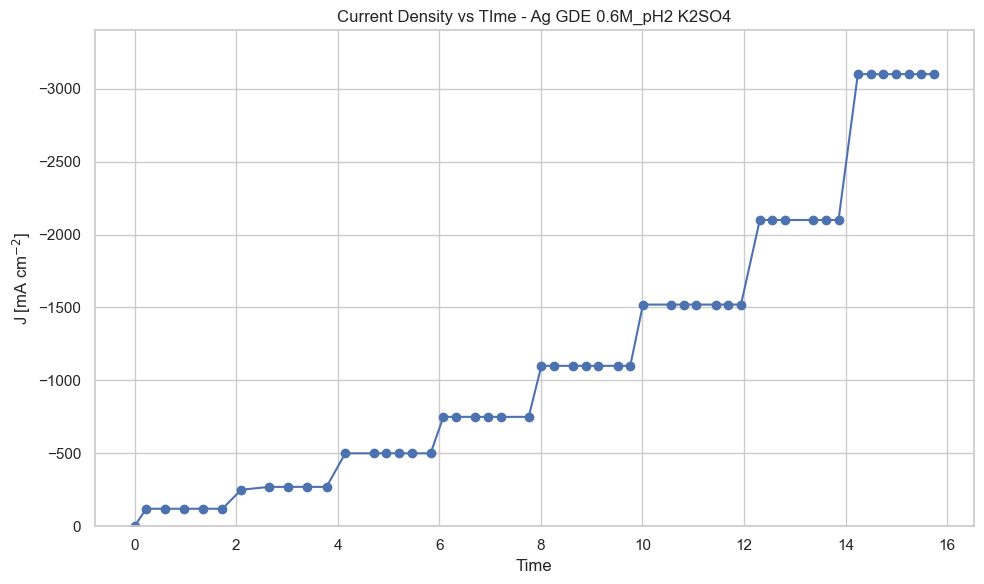

In [97]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.6M_pH2 K2SO4')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

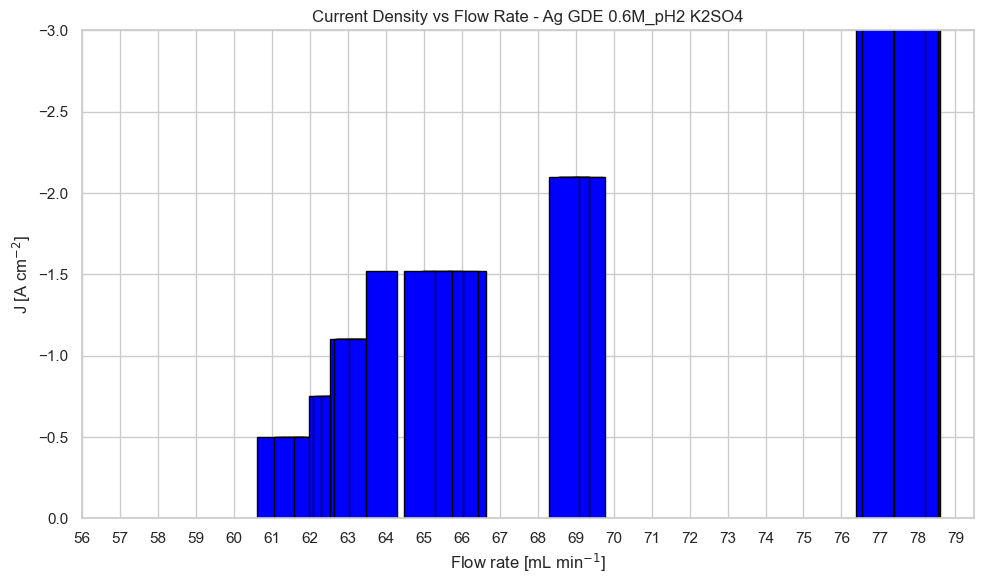

In [98]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.6M_pH2 K2SO4')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


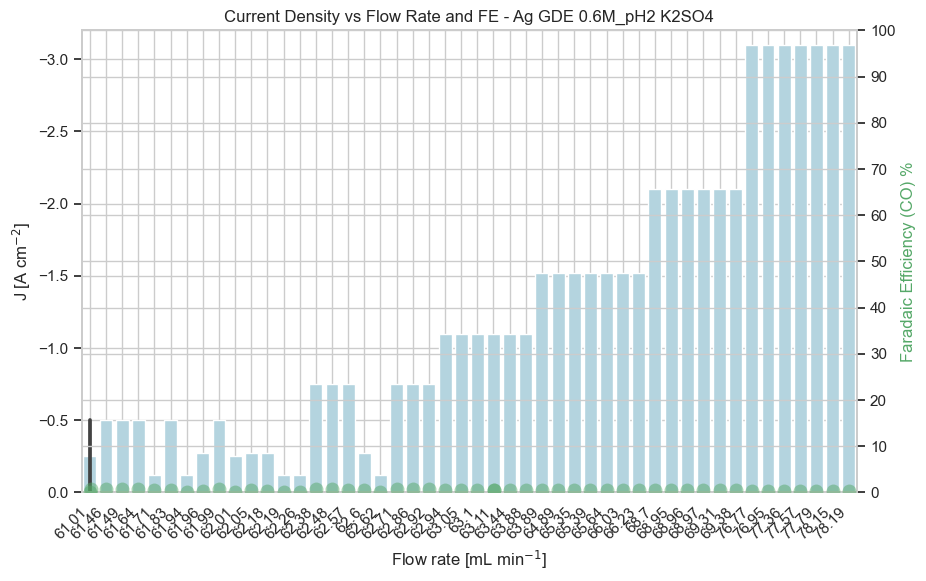

In [99]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.6M_pH2 K2SO4')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240605_Ag_GDE_0_6M_pH2_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [100]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [101]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240605 - Ag60 GDE_0.6 M K2SO4_pH2

11-Aug-26  09:15 AM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  08:28 PM    <DIR>          .ipynb_checkpoints
07-Jun-24  03:02 PM            86,996 0p6M_pH2 K2SO4_20240607_1301_1min - Copy.xlsx
29-Jul-26  05:49 PM           103,550 0p6M_pH2 K2SO4_20240607_1301_1min.xlsx
07-Jun-24  03:02 PM            22,037 0p6M_pH2 K2SO4_20240607_1301_5min.xlsx
07-Jun-24  03:02 PM           699,826 0p6M_pH2 K2SO4_20240607_1301_Line_1.csv
17-Jul-26  11:25 AM           917,401 20240605 - Ag60 GDE_0.6 M K2SO4_pH2.ipynb
11-Aug-26  09:15 AM           819,036 20240605 - Ag60 GDE_0.6 M K2SO4_pH2-CORRECTED.ipynb
11-Aug-26  09:09 AM               565 20240605_0.6 M K2SO4_pH2_Energy Consumption.csv
03-Aug-26  05:26 PM             5,323 20240605_0.6M K2SO4_pH2.csv
11-Aug-26  09:09 AM             1,435 20

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


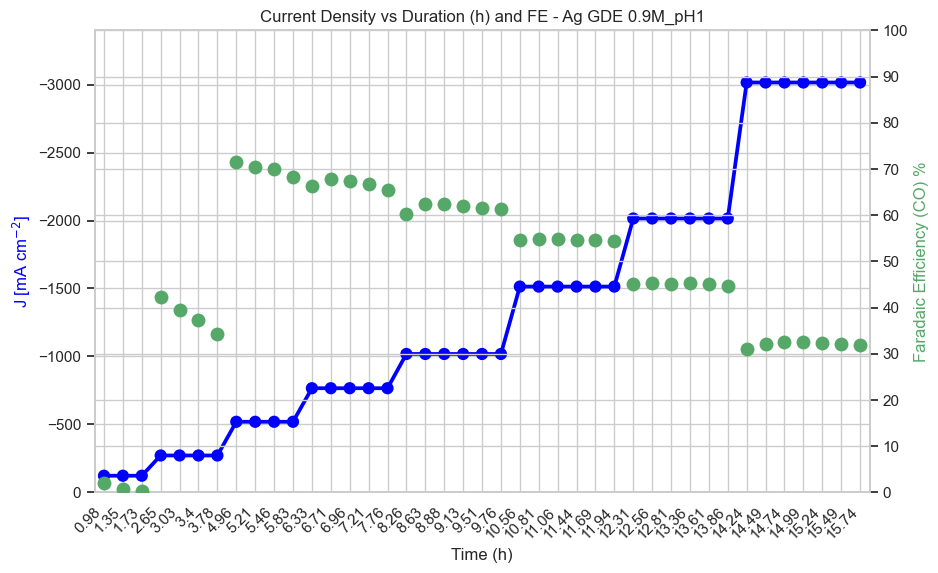

In [102]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.9M_pH1')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240605_Ag_GDE_0_6M_pH2_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

##### Drop points from initial step in each current

In [103]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.23].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.6].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.1].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.15].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.71].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.01].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.01].index)
# rows = rows.drop(rows[rows['Duration / h'] == 14.02].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
3,Ag60 GDE in PTFE holder,60,62.62,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-05 18:40:36,0.98,1.433771,...,62.62,0.0,-122.0,0.12,0.122,59.722717,59.028098,60.645689,59.816346,88.448325
4,Ag60 GDE in PTFE holder,60,61.94,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-05 19:03:05,1.35,1.463894,...,61.94,1.0,-122.0,0.12,0.122,59.722717,59.028098,60.645689,59.816346,89.641701
5,Ag60 GDE in PTFE holder,60,62.19,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.122,2024-06-05 19:25:36,1.73,1.480378,...,62.19,1.0,-122.0,0.12,0.122,59.722717,59.028098,60.645689,59.816346,89.596922
7,Ag60 GDE in PTFE holder,60,62.05,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.271,2024-06-05 20:21:10,2.65,1.818008,...,62.05,2.0,-271.0,0.27,0.271,60.178392,59.442683,61.357145,60.191775,92.114962
8,Ag60 GDE in PTFE holder,60,62.60,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.271,2024-06-05 20:43:40,3.03,1.945025,...,62.60,3.0,-271.0,0.27,0.271,60.178392,59.442683,61.357145,60.191775,92.871894
9,Ag60 GDE in PTFE holder,60,61.96,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.271,2024-06-05 21:06:12,3.40,2.031874,...,61.96,3.0,-271.0,0.27,0.271,60.178392,59.442683,61.357145,60.191775,92.966998
10,Ag60 GDE in PTFE holder,60,62.18,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.271,2024-06-05 21:28:43,3.78,2.130583,...,62.18,3.0,-271.0,0.27,0.271,60.178392,59.442683,61.357145,60.191775,92.732405
11,Ag60 GDE in PTFE holder,60,61.99,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.519,2024-06-05 23:31:48,5.83,1.613981,...,61.99,5.0,-519.0,0.50,0.519,60.337637,59.449509,61.273466,60.33241,91.538607
12,Ag60 GDE in PTFE holder,60,61.46,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.519,2024-06-05 23:09:18,5.46,1.529569,...,61.46,5.0,-519.0,0.50,0.519,60.337637,59.449509,61.273466,60.33241,92.165793
13,Ag60 GDE in PTFE holder,60,61.01,0.3 M K2SO4,Deionized wated,CCM-CEM,-0.519,2024-06-05 22:54:18,5.21,1.466225,...,61.01,5.0,-519.0,0.50,0.519,60.337637,59.449509,61.273466,60.33241,91.663429


## Current Density vs FE(CO)_ mean and std

### Stacked bar plot

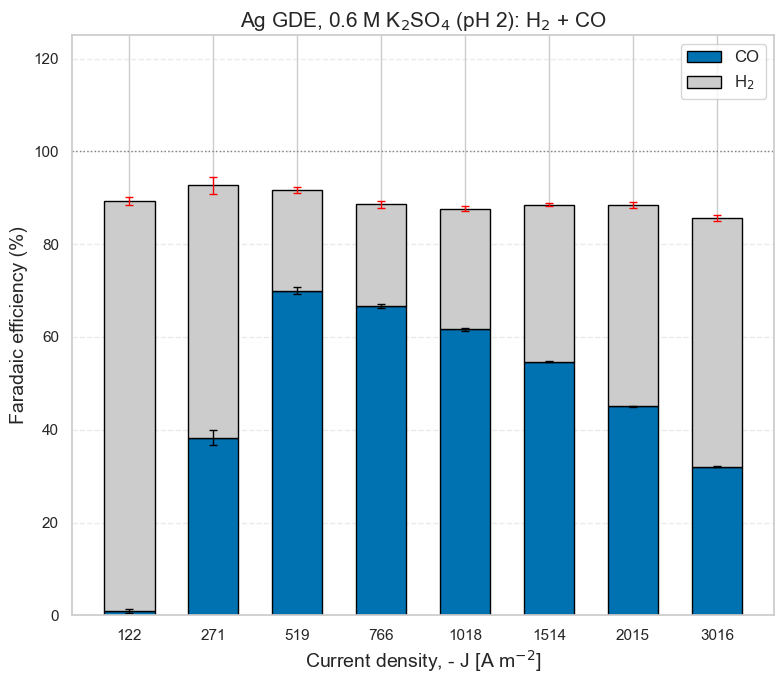

In [104]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M K$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

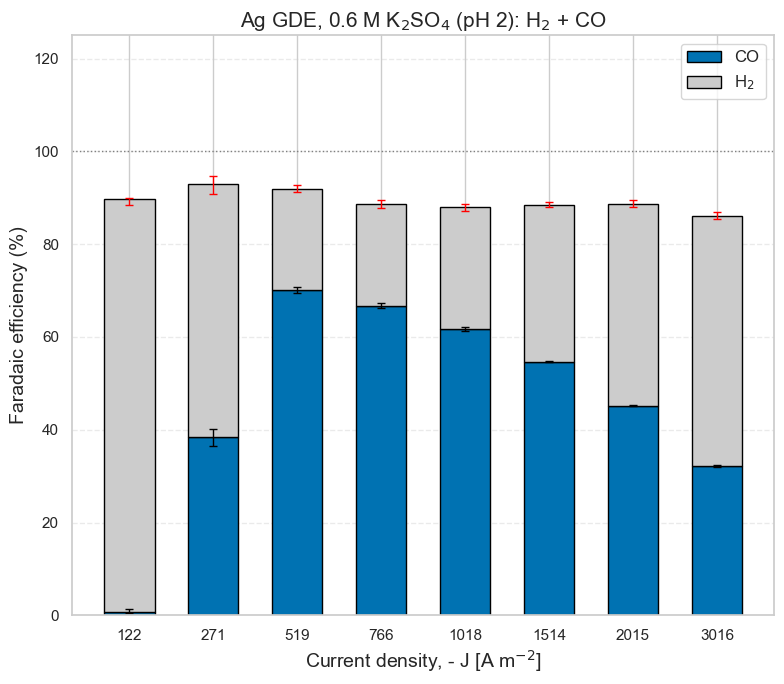

In [107]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.6 M K$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [108]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [109]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,88.249300,0.979683,88.868539,0.773162,0.868261,0.490599,1.503873,0.849742,87.701607,...,0.013736,3,1.166932,0.238074,0.260463,0.570244,0.574298,0.022389,0–2,122
1,250,54.366276,38.305289,54.562803,38.356643,1.801225,1.671357,3.602450,3.342714,52.517946,...,0.018617,4,2.044857,1.848330,1.859426,1.808072,0.224105,0.093520,2–4,271
2,500,21.727818,70.000647,21.706434,70.208177,0.689477,0.678341,1.378955,1.356682,20.938217,...,0.014151,4,0.768217,0.789601,0.695216,0.487686,0.060555,0.184290,4–6,519
3,750,21.855028,66.715751,22.012787,66.744880,0.757367,0.399892,1.693525,0.894187,21.027161,...,0.021283,5,0.985626,0.689118,0.537390,0.560931,0.494318,0.128186,6–8,766
4,1000,26.034968,61.636236,26.286204,61.743790,0.568387,0.338472,1.392257,0.829084,25.503176,...,0.033422,6,0.783028,0.652989,0.406427,0.486989,0.480304,0.123111,8–10,1018
5,1500,33.855242,54.655648,33.879370,54.633602,0.363065,0.069499,0.889325,0.170237,33.323745,...,0.063241,6,0.555626,0.581208,0.098700,0.149808,0.356365,0.533968,10–12,1514
6,2000,43.305682,45.096431,43.567724,45.152700,0.583708,0.112592,1.429786,0.275794,42.816237,...,0.104254,6,0.751486,0.709974,0.116850,0.106894,0.758371,0.503534,12–14,2015
7,3000,53.647612,32.072074,54.047725,32.117264,0.656192,0.198102,1.736120,0.524128,53.248907,...,0.184375,7,0.798818,0.701627,0.137666,0.285321,1.076337,0.303509,14–16,3016


In [112]:
Res_Book
# Res_Book.to_csv('20240605_0.6M K2SO4_pH2.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,88.249300,0.979683,88.868539,0.773162,0.868261,0.490599,1.503873,0.849742,87.701607,...,0.013736,3,1.166932,0.238074,0.260463,0.570244,0.574298,0.022389,0–2,122
1,250,54.366276,38.305289,54.562803,38.356643,1.801225,1.671357,3.602450,3.342714,52.517946,...,0.018617,4,2.044857,1.848330,1.859426,1.808072,0.224105,0.093520,2–4,271
2,500,21.727818,70.000647,21.706434,70.208177,0.689477,0.678341,1.378955,1.356682,20.938217,...,0.014151,4,0.768217,0.789601,0.695216,0.487686,0.060555,0.184290,4–6,519
3,750,21.855028,66.715751,22.012787,66.744880,0.757367,0.399892,1.693525,0.894187,21.027161,...,0.021283,5,0.985626,0.689118,0.537390,0.560931,0.494318,0.128186,6–8,766
4,1000,26.034968,61.636236,26.286204,61.743790,0.568387,0.338472,1.392257,0.829084,25.503176,...,0.033422,6,0.783028,0.652989,0.406427,0.486989,0.480304,0.123111,8–10,1018
5,1500,33.855242,54.655648,33.879370,54.633602,0.363065,0.069499,0.889325,0.170237,33.323745,...,0.063241,6,0.555626,0.581208,0.098700,0.149808,0.356365,0.533968,10–12,1514
6,2000,43.305682,45.096431,43.567724,45.152700,0.583708,0.112592,1.429786,0.275794,42.816237,...,0.104254,6,0.751486,0.709974,0.116850,0.106894,0.758371,0.503534,12–14,2015
7,3000,53.647612,32.072074,54.047725,32.117264,0.656192,0.198102,1.736120,0.524128,53.248907,...,0.184375,7,0.798818,0.701627,0.137666,0.285321,1.076337,0.303509,14–16,3016


## Mean and StD of FE(CO) through time

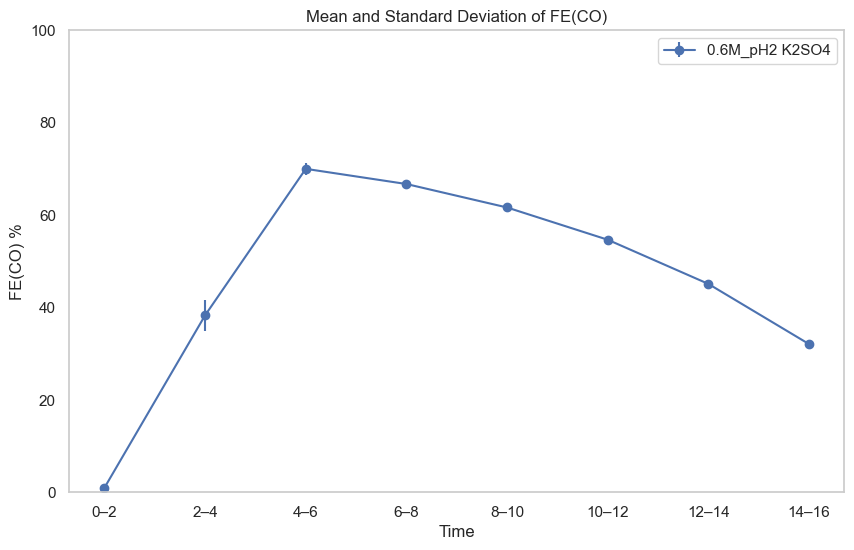

In [113]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.6M_pH2 K2SO4')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240605_0.6M_pH2_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

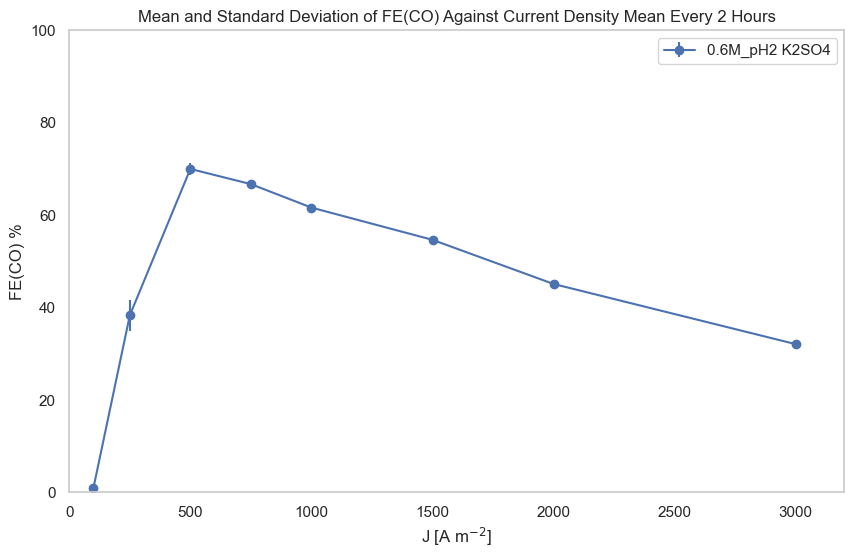

In [114]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.6M_pH2 K2SO4')

# Formatting the plot
ax.set_xlabel(r'J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240605_0.6M_pH2_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()